<h1>Outlier Detection</h1>

<h2>What are Outliers?</h2>

Outliers are data values that are significantly higher or lower than the rest of the observations.

They may occur due to measurement errors, data entry mistakes, or genuine rare events.

Example:

Student marks : 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 150

Here, 150 is much higher than the other marks, so it is an outlier.

In [1]:
import pandas as pd

marks = [45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 150]

data = pd.DataFrame({"Marks": marks})

print(data)

    Marks
0      45
1      50
2      55
3      60
4      65
5      70
6      75
7      80
8      85
9      90
10     95
11    150


The value 150 is far from the rest of the data and is considered an outlier.

<h2>Types of Outliers</h2>

Outliers can be classified into three types:

Global Outlier: A value that is very different from all other values. 

Contextual Outlier: A value that is unusual only in a specific context. 

Collective Outlier: A group of unusual observations occurring together.

Example:

Using the marks dataset:

<ul><li>150 - Global Outlier</li>
    
<li>A student scoring 95 in a very difficult exam - Contextual Outlier</li>

<li>A group of students scoring 0 due to a system error - Collective Outlier</li></ul>

In [2]:
print(data)

    Marks
0      45
1      50
2      55
3      60
4      65
5      70
6      75
7      80
8      85
9      90
10     95
11    150


Different types of outliers help identify unusual observations in different situations.

<h2>Detecting Outliers</h2>

Outlier detection is the process of identifying observations that are very different from the rest of the dataset.

Methods include:

<ul><li>IQR Method</li>
<li>Z-Score Method</li>
<li>Box Plot</li>
<li>Scatter Plot</li></ul>
    
Example:

The teacher wants to identify whether 150 is an unusual mark.

In [3]:
print(data.describe())

            Marks
count   12.000000
mean    76.666667
std     27.988093
min     45.000000
25%     58.750000
50%     72.500000
75%     86.250000
max    150.000000


Summary statistics help identify values that appear unusually high or low.

<h2>IQR Method</h2>

The Interquartile Range (IQR) method identifies outliers using the middle 50% of the data.

Formula:

IQR = Q3 − Q1

Lower Limit = Q1 − 1.5 × IQR

Upper Limit = Q3 + 1.5 × IQR

Example:

The value 150 lies above the upper limit, so it is detected as an outlier.

In [5]:
Q1 = data["Marks"].quantile(0.25)
Q3 = data["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data["Marks"] < lower) | (data["Marks"] > upper)]
print(outliers)

    Marks
11    150


The IQR method identifies values that fall outside the normal range.

<h2>Z-Score Method</h2>

The Z-Score Method measures how many standard deviations a value is from the mean.

A value with an absolute Z-score greater than 3 is often considered an outlier.

Example:

The teacher calculates the Z-score of each student's mark.

The score 150 has a very high Z-score.

In [6]:
import numpy as np

mean = data["Marks"].mean()
std = data["Marks"].std()

data["Z-Score"] = (data["Marks"] - mean) / std

print(data)

    Marks   Z-Score
0      45 -1.131434
1      50 -0.952786
2      55 -0.774139
3      60 -0.595491
4      65 -0.416844
5      70 -0.238197
6      75 -0.059549
7      80  0.119098
8      85  0.297746
9      90  0.476393
10     95  0.655040
11    150  2.620162


Values with large positive or negative Z-scores may be considered outliers

<h2>Box Plot</h2>

A Box Plot is a graphical method used to visualize the spread of data and identify outliers.

Points outside the whiskers are potential outliers.

Example:

The box plot clearly shows 150 as an outlier.

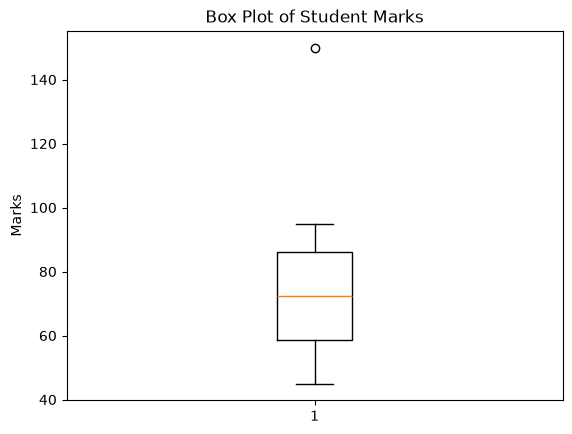

In [7]:
import matplotlib.pyplot as plt

plt.boxplot(data["Marks"])

plt.title("Box Plot of Student Marks")
plt.ylabel("Marks")

plt.show()

Any point outside the whiskers is considered a possible outlier.

<h2>Scatter Plot</h2>

A Scatter Plot displays individual data points and helps identify observations that are far from the rest.

Example:

The mark 150 appears much higher than all other students.

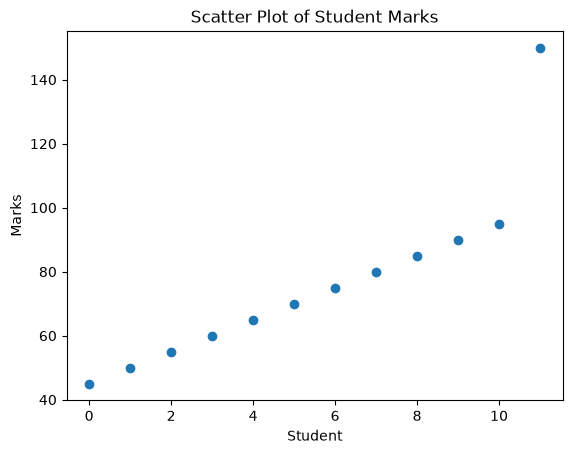

In [8]:
import matplotlib.pyplot as plt

plt.scatter(range(len(data)), data["Marks"])

plt.xlabel("Student")
plt.ylabel("Marks")
plt.title("Scatter Plot of Student Marks")

plt.show()

The point at 150 is visually separated from the remaining observations, making it easy to identify as an outlier.